In [16]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
train = pd.read_csv("data/train.txt", sep=" ", header=None)

In [4]:
train.shape

(10496, 3)

In [5]:
train.head()

,0,1,2
0,939,3809,1
1,2442,5784,1
2,179,3809,1
3,857,2280,1
4,1358,5722,1


In [6]:
train.columns = ["source", "target", "label"]
train.head()

,source,target,label
0,939,3809,1
1,2442,5784,1
2,179,3809,1
3,857,2280,1
4,1358,5722,1


In [ ]:
train["label"].value_counts()

#pas de problème de données d'apprentissage déséquilibrées !!!

label
1    5248
0    5248
Name: count, dtype: int64

In [ ]:
nodes = set(train["source"]).union(set(train["target"]))
len(nodes) #nombre de noeuds uniques 

3597

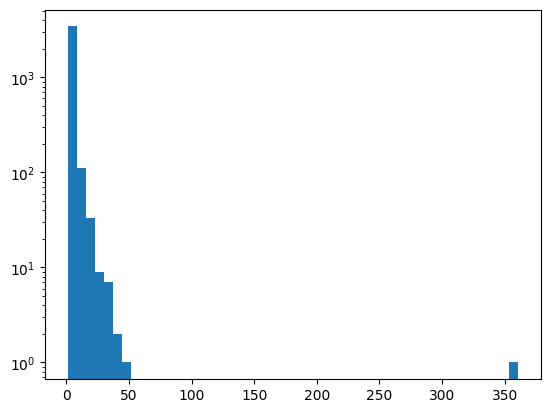

In [18]:
G = nx.Graph()
edges = train[train["label"] == 1][["source", "target"]].values
G.add_edges_from(edges)

degrees = [d for _, d in G.degree()]

plt.hist(degrees, bins=50)
plt.yscale('log')

In [ ]:
max_degree_node = max(G.degree, key=lambda x: x[1])
max_degree_node #le noeud ultra connecté 

(np.int64(3809), 361)

In [20]:
def common_neighbors(u, v):
    return len(list(nx.common_neighbors(G, u, v)))

train["cn"] = train.apply(lambda x: common_neighbors(x.source, x.target), axis=1)

In [21]:
train.groupby("label")["cn"].mean()

label
0    0.014101
1    0.141578
Name: cn, dtype: float64

In [ ]:
train["cn_positive"] = (train["cn"] > 0).astype(int)
train.groupby(["cn_positive", "label"]).size()

#avoir un nombre de voisins communs nul n'est pas si informatif que ça en fait...

cn_positive  label
0            0        5174
             1        4712
1            0          74
             1         536
dtype: int64

In [ ]:
positive_nodes = set(train[train["label"] == 1]["source"]).union(set(train[train["label"] == 1]["target"]))
len(positive_nodes) #donc tous les noeuds ont au moins un vrai voisin => graphe connecté 

3597

In [10]:
node_info = pd.read_csv("data/node_information.csv", header=None)

In [11]:
node_info.shape

(3597, 933)

In [12]:
node_info.head()

,0,1,2,3,4,5,6,7,8,9,...,923,924,925,926,927,928,929,930,931,932
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
node_info = node_info.rename(columns={0: "node"})
node_info.head()

,node,1,2,3,4,5,6,7,8,9,...,923,924,925,926,927,928,929,930,931,932
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
csv_nodes = set(node_info["node"])
nodes == csv_nodes #pour être sûr, parfait 

True

In [26]:
features = node_info.drop(columns=["node"])
features != 0
non_zero_counts = (features != 0).sum(axis=1)

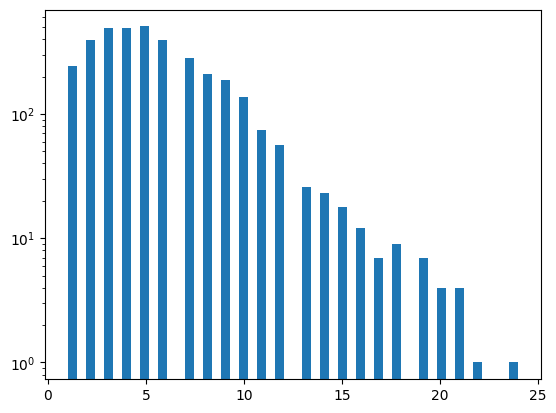

In [30]:
plt.hist(non_zero_counts, bins=50)
plt.yscale("log")

In [ ]:
all_zero_nodes = (features == 0).all(axis=1)
all_zero_nodes.sum() #tous les noeuds ont au moins une feature non nulle, ouf 

np.int64(0)

In [33]:
features = node_info.set_index("node")

In [34]:
def common_features(u, v):
    u_vec = features.loc[u].values
    v_vec = features.loc[v].values
    
    return ((u_vec != 0) & (v_vec != 0)).sum()

In [35]:
train["common_feat"] = train.apply(
    lambda x: common_features(x.source, x.target),
    axis=1
)

In [ ]:
train.groupby("label")["common_feat"].mean()

#coup dur 

label
0    0.836700
1    0.830221
Name: common_feat, dtype: float64

In [37]:
def jaccard_features(u, v):
    u_vec = features.loc[u].values
    v_vec = features.loc[v].values
    
    intersection = ((u_vec != 0) & (v_vec != 0)).sum()
    union = ((u_vec != 0) | (v_vec != 0)).sum()
    
    if union == 0:
        return 0
    
    return intersection / union

In [ ]:
train["jaccard_feat"] = train.apply(
    lambda x: jaccard_features(x.source, x.target),
    axis=1
)

train.groupby("label")["jaccard_feat"].mean()

#encore plus coup dur

label
0    0.093085
1    0.094681
Name: jaccard_feat, dtype: float64

In [39]:
features = node_info.drop(columns=["node"])
feature_counts = (features != 0).sum(axis=0)

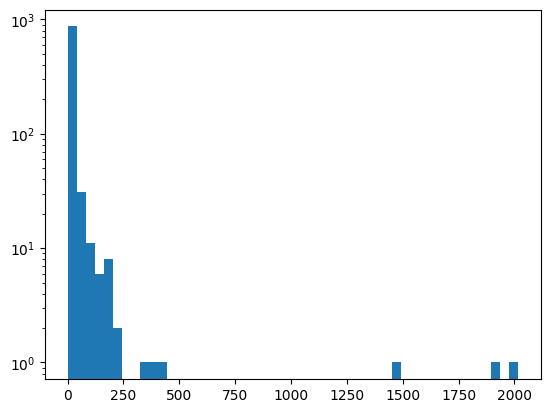

In [ ]:
plt.hist(feature_counts, bins=50)
plt.yscale("log")

In [ ]:
(feature_counts == 0).sum() #3 features sont totalement inutiles 

np.int64(3)

In [61]:
feature_counts.value_counts()

3     114
5     108
4     107
2      69
6      67
     ... 
37      1
55      1
98      1
94      1
82      1
Name: count, Length: 90, dtype: int64

In [62]:
features = node_info.set_index("node")

from sklearn.metrics.pairwise import cosine_similarity

def cosine(u, v):
    u_vec = features.loc[u].values.reshape(1, -1)
    v_vec = features.loc[v].values.reshape(1, -1)
    
    return cosine_similarity(u_vec, v_vec)[0][0]

In [63]:
train["cosine"] = train.apply(
    lambda x: cosine(x.source, x.target),
    axis=1
)

In [ ]:
train.groupby("label")["cosine"].mean()

#vraiment très très coup dur 

label
0    0.16162
1    0.15879
Name: cosine, dtype: float64

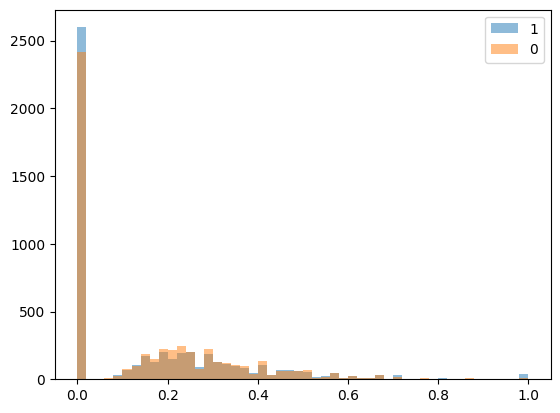

In [67]:
plt.hist(train[train["label"] == 1]["cosine"], bins=50, alpha=0.5, label="1")
plt.hist(train[train["label"] == 0]["cosine"], bins=50, alpha=0.5, label="0")
plt.legend()

In [ ]:
train["cn_cosine"] = train["cn"] * train["cosine"]
train.groupby("label")["cn_cosine"].mean()

#ahhhh sauvés 

label
0    0.002351
1    0.046708
Name: cn_cosine, dtype: float64

In [71]:
train["cn_plus_cosine"] = train["cn"] + train["cosine"]
train.groupby("label")["cn_plus_cosine"].mean()

label
0    0.175721
1    0.300368
Name: cn_plus_cosine, dtype: float64

In [ ]:
#donc les features qui sont des features combinées ont l'air d'être plus discriminates (c'était bien ce 
#qui s'est vu dans les scores Kaggle)